# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [1]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% This loads the Octave control-systems "package," which implements the "ss" and "lsim" commands.
pkg load control

### The nearly constant position model
The next notebook cells demonstrate the nearly constant position model

In [2]:
% Define the NCP model
A = zeros(2); Bw = eye(2);
C = eye(2);   D = zeros(2);
ncp = ss(A,Bw,C,D);

In [3]:
% Simulate the NCP model
randn("state",0); % Don't change this line since it affects the simulation results that are used in the quiz
tncp = (0:999)*0.1;
wncp = 0.05*randn(2,1000);
vncp = 0.01*randn(2,1000);
zncp = lsim(ncp,wncp',tncp)+vncp';

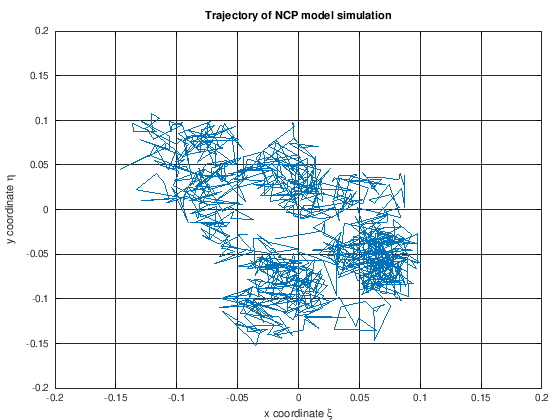

In [4]:
% Plot the simulation output
plot(zncp(:,1),zncp(:,2));
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of NCP model simulation');
grid on

In [5]:
% Display the final coordinate of the trajectory
zncp(end,:)

ans =

  -0.019323  -0.033038



### The nearly constant velocity model
The next notebook cells demonstrate the nearly constant velocity model

In [6]:
% Define the NCV model
A  = [0 1 0 0; 0 0 0 0; ...
      0 0 0 1; 0 0 0 0];
Bw = [0 0; 1 0; 0 0; 0 1];
C  = [1 0 0 0; 0 0 1 0]; 
D  = zeros(2);
ncv = ss(A,Bw,C,D);

In [7]:
% Simulate the NCV model
randn("state",0); % Don't change this line since it affects the simulation results that are used in the quiz
tncv = (0:999)*0.1;
wncv = 0.05*randn(2,1000);
vncv = 0.01*randn(2,1000);
zncv = lsim(ncv,wncv',tncv)+vncv';

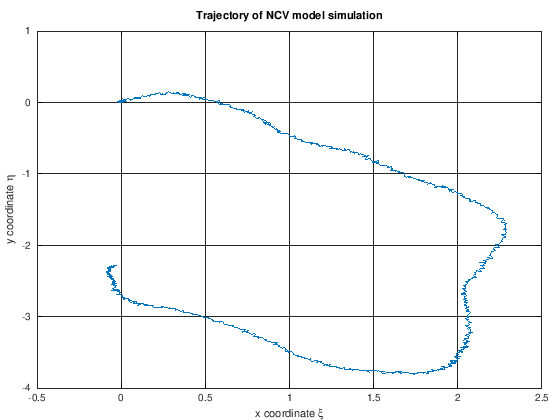

In [8]:
% Plot the simulation output
plot(zncv(:,1),zncv(:,2));
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of NCV model simulation');
grid on

In [9]:
% Display the final coordinate of the trajectory
zncv(end,:)

ans =

  -0.067324  -2.313042



### The coordinated-turn model
The next notebook cells demonstrate the coordinated-turn model

In [10]:
% Define the CT model
W  = 0.01; % Value of Omega
A  = [0 1 0 0; 0 0 0 -W; ...
      0 0 0 1; 0 W 0 0];
Bw = [0 0; 1 0; 0 0; 0 1];
C  = [1 0 0 0; 0 0 1 0]; 
D  = zeros(2);
ct = ss(A,Bw,C,D);

In [11]:
% Simulate the CT model
randn("state",0); % Don't change this line since it affects the simulation results that are used in the quiz
tct = (0:999)*01;
wct = 0.01*randn(2,1000);
vct = 0.001*randn(2,1000);
zct = lsim(ct,wct',tct)+vct';

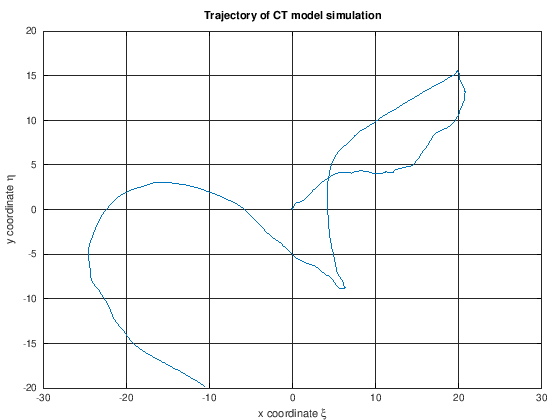

In [12]:
% Plot the output of the CT model
plot(zct(:,1),zct(:,2));
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of CT model simulation');
grid on

In [13]:
% Display the final coordinate of the trajectory
zct(end,:)

ans =

  -10.513  -19.863

